In [5]:
# Install wordcloud library
!pip install wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string

# NLP libraries
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [10]:
url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv"
df = pd.read_csv(url)

# Check actual column names first
print("Actual columns:", list(df.columns))
print("Shape:", df.shape)
df.head(3)

Actual columns: ['reviewText', 'Positive']
Shape: (20000, 2)


,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1


Dataset ready!
Rows: 20000, Columns: 2

Score distribution:
Score
0     4767
1    15233
Name: count, dtype: int64


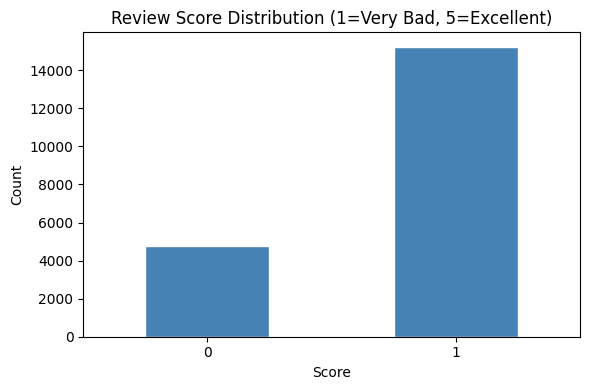

In [12]:
# Rename columns based on what we saw
# Column 1 = review text, Column 2 = score
df.columns = ['Text', 'Score']
df = df.dropna()

# Convert Score to number
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
df = df.dropna()

print("Dataset ready!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nScore distribution:")
print(df['Score'].value_counts().sort_index())

plt.figure(figsize=(6,4))
df['Score'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Review Score Distribution (1=Very Bad, 5=Excellent)')
plt.xlabel('Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== SENTIMENT DISTRIBUTION ===
Sentiment
Positive    15233
Negative     4767
Name: count, dtype: int64

Positive rate: 76.2%
Negative rate: 23.8%


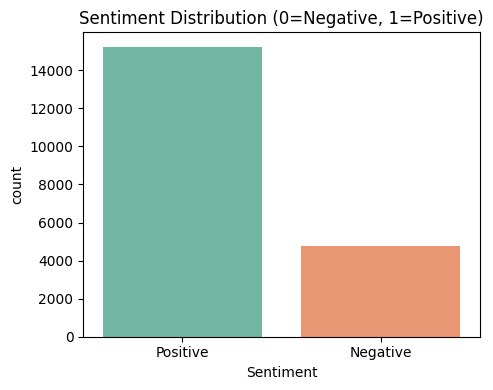

In [13]:
# Labels already exist as 0 and 1 — no need to create them!
df['Sentiment'] = df['Score'].map({1: 'Positive', 0: 'Negative'})

print("=== SENTIMENT DISTRIBUTION ===")
print(df['Sentiment'].value_counts())
print(f"\nPositive rate: {(df['Score']==1).mean()*100:.1f}%")
print(f"Negative rate: {(df['Score']==0).mean()*100:.1f}%")

plt.figure(figsize=(5,4))
sns.countplot(x='Sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution (0=Negative, 1=Positive)')
plt.tight_layout()
plt.show()

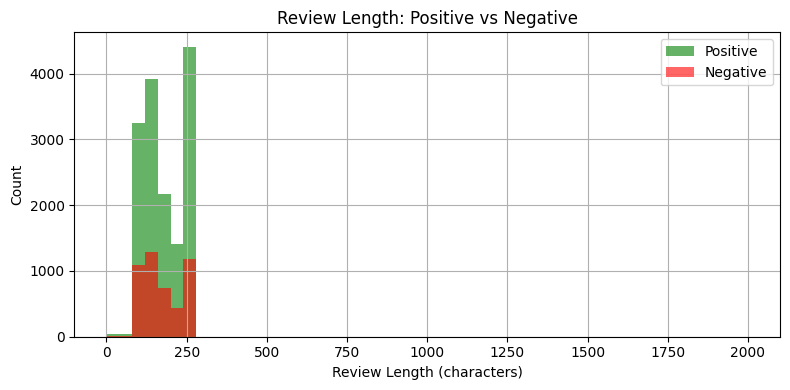

Avg Positive length: 177 chars
Avg Negative length: 172 chars


In [14]:
df['review_length'] = df['Text'].astype(str).apply(len)

plt.figure(figsize=(8,4))
df[df['Sentiment']=='Positive']['review_length'].hist(
    alpha=0.6, color='green', bins=50, label='Positive', range=(0,2000))
df[df['Sentiment']=='Negative']['review_length'].hist(
    alpha=0.6, color='red', bins=50, label='Negative', range=(0,2000))
plt.title('Review Length: Positive vs Negative')
plt.xlabel('Review Length (characters)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Avg Positive length: {df[df['Sentiment']=='Positive']['review_length'].mean():.0f} chars")
print(f"Avg Negative length: {df[df['Sentiment']=='Negative']['review_length'].mean():.0f} chars")

In [15]:
print("=== 3 POSITIVE REVIEWS ===")
for i, row in df[df['Sentiment']=='Positive'].head(3).iterrows():
    print(f"→ {str(row['Text'])[:150]}...")
    print()

print("=== 3 NEGATIVE REVIEWS ===")
for i, row in df[df['Sentiment']=='Negative'].head(3).iterrows():
    print(f"→ {str(row['Text'])[:150]}...")
    print()

=== 3 POSITIVE REVIEWS ===
→ This is a one of the best apps acording to a bunch of people and I agree it has bombs eggs pigs TNT king pigs and realustic stuff...

→ This is a pretty good version of the game for being free. There are LOTS of different levels to play. My kids enjoy it a lot too....

→ this is a really cool game. there are a bunch of levels and you can find golden eggs. super fun....

=== 3 NEGATIVE REVIEWS ===
→ They call it three next mario??? Are the 'professional reviewers' high??? Ask you do is fling birds at bones again and again and again. Has zero repla...

→ Angry People in my book!  Any moron who would waste their time playing azimuth slingshot and call it a cultural phenomenon is ... what is the word (??...

→ Argry Birds is for free to play a games on your kindlefireBecause it for free. and to play right....



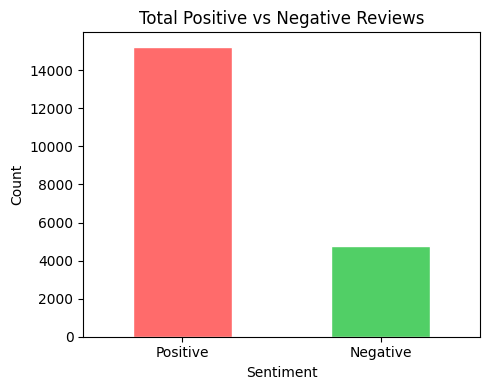

Total reviews  : 20,000
Positive       : 15,233
Negative       : 4,767


In [16]:
plt.figure(figsize=(5,4))
colors = ['#FF6B6B', '#51CF66']
df['Sentiment'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Total Positive vs Negative Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Total reviews  : {len(df):,}")
print(f"Positive       : {(df['Sentiment']=='Positive').sum():,}")
print(f"Negative       : {(df['Sentiment']=='Negative').sum():,}")

In [17]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Test it
sample = "This product is AMAZING!! I loved it so much. 10/10 would buy again!"
print("Original :", sample)
print("Cleaned  :", clean_text(sample))

Original : This product is AMAZING!! I loved it so much. 10/10 would buy again!
Cleaned  : product amazing loved much would buy


In [19]:
print("⏳ Cleaning all reviews — please wait...")
df['clean_text'] = df['Text'].apply(clean_text)

print("All reviews cleaned!")
print(f"\nOriginal : {str(df['Text'].iloc[0])[:120]}")
print(f"Cleaned  : {df['clean_text'].iloc[0][:120]}")

⏳ Cleaning all reviews — please wait...
All reviews cleaned!

Original : This is a one of the best apps acording to a bunch of people and I agree it has bombs eggs pigs TNT king pigs and realus
Cleaned  : one best apps acording bunch people agree bombs eggs pigs tnt king pigs realustic stuff


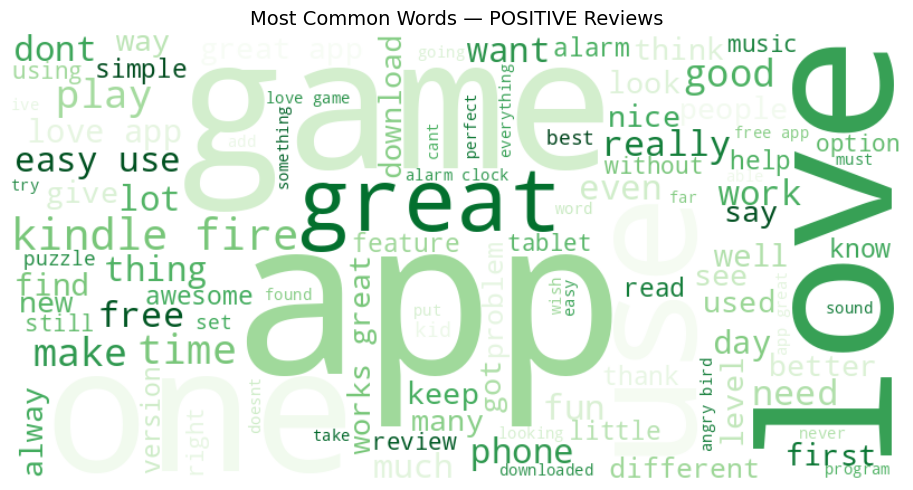

In [20]:
positive_text = ' '.join(df[df['Sentiment']=='Positive']['clean_text'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Greens',
                      max_words=100).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words — POSITIVE Reviews', fontsize=14)
plt.tight_layout()
plt.show()

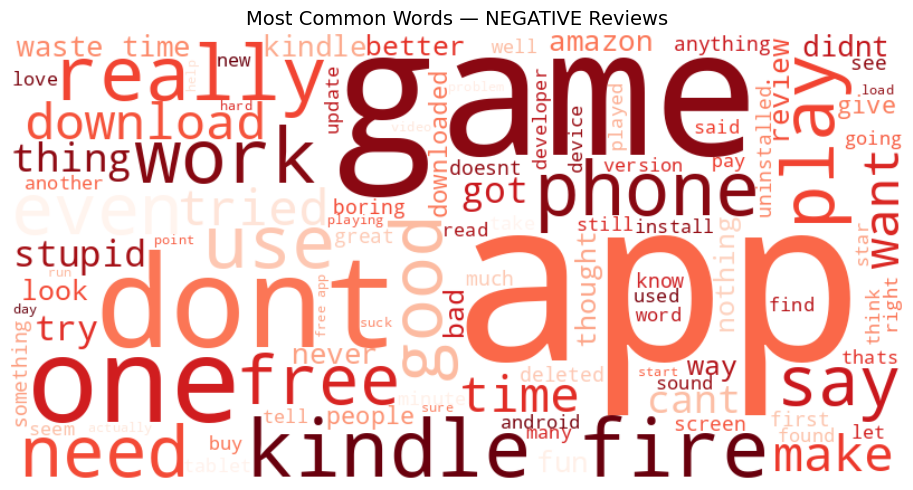

In [21]:
negative_text = ' '.join(df[df['Sentiment']=='Negative']['clean_text'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Reds',
                      max_words=100).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words — NEGATIVE Reviews', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# Labels already clean — Score column IS our label (0 or 1)
y = df['Score']

print("=== LABEL CHECK ===")
print(y.value_counts())
print(f"\nTotal reviews for modeling: {len(df):,}")

=== LABEL CHECK ===
Score
1    15233
0     4767
Name: count, dtype: int64

Total reviews for modeling: 20,000


In [24]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X = tfidf.fit_transform(df['clean_text'])

print("TF-IDF complete!")
print(f"Feature matrix shape : {X.shape}")
print(f"Vocabulary size      : {len(tfidf.vocabulary_):,}")
print(f"\nSample features: {list(tfidf.vocabulary_.keys())[:15]}")

TF-IDF complete!
Feature matrix shape : (20000, 5000)
Vocabulary size      : 5,000

Sample features: ['one', 'best', 'apps', 'bunch', 'people', 'agree', 'eggs', 'pigs', 'king', 'stuff', 'one best', 'best apps', 'pretty', 'good', 'version']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/Test split done!")
print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print(f"Positive in test : {y_test.mean()*100:.1f}%")

Train/Test split done!
Training samples : 16,000
Testing samples  : 4,000
Positive in test : 76.2%


In [27]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred  = nb_model.predict(X_test)
nb_acc   = accuracy_score(y_test, nb_pred)

print("=== NAIVE BAYES ===")
print(f"Accuracy: {nb_acc*100:.2f}%")

=== NAIVE BAYES ===
Accuracy: 88.55%


In [28]:
lg_model = LogisticRegression(max_iter=1000, random_state=42)
lg_model.fit(X_train, y_train)
lg_pred  = lg_model.predict(X_test)
lg_acc   = accuracy_score(y_test, lg_pred)

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {lg_acc*100:.2f}%")

=== LOGISTIC REGRESSION ===
Accuracy: 89.42%


In [29]:
print("=" * 42)
print("      MODEL COMPARISON REPORT")
print("=" * 42)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 42)
print(f"{'Naive Bayes':<25} {nb_acc*100:>9.2f}%")
print(f"{'Logistic Regression':<25} {lg_acc*100:>9.2f}%")
print("=" * 42)

best_pred = lg_pred if lg_acc > nb_acc else nb_pred
best_name = 'Logistic Regression' if lg_acc > nb_acc else 'Naive Bayes'
best_acc  = max(lg_acc, nb_acc)
print(f"\n🏆 Best Model: {best_name} ({best_acc*100:.2f}%)")

print(f"\n📊 Detailed Report ({best_name}):")
print(classification_report(y_test, best_pred,
      target_names=['Negative', 'Positive']))

      MODEL COMPARISON REPORT
Model                       Accuracy
------------------------------------------
Naive Bayes                   88.55%
Logistic Regression           89.42%

🏆 Best Model: Logistic Regression (89.42%)

📊 Detailed Report (Logistic Regression):
              precision    recall  f1-score   support

    Negative       0.87      0.66      0.75       953
    Positive       0.90      0.97      0.93      3047

    accuracy                           0.89      4000
   macro avg       0.88      0.81      0.84      4000
weighted avg       0.89      0.89      0.89      4000



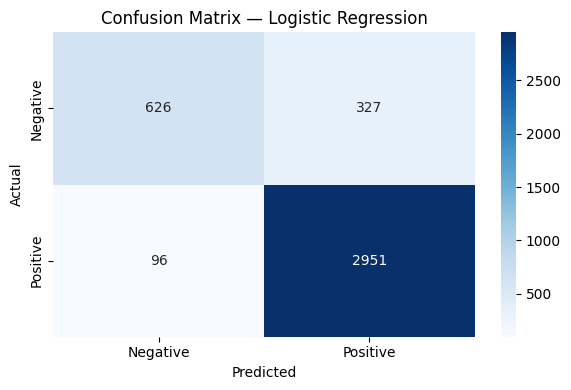

✅ Correctly identified Positive : 2,951
✅ Correctly identified Negative : 626
❌ Wrong predictions             : 423


In [30]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"✅ Correctly identified Positive : {tp:,}")
print(f"✅ Correctly identified Negative : {tn:,}")
print(f"❌ Wrong predictions             : {fp+fn:,}")

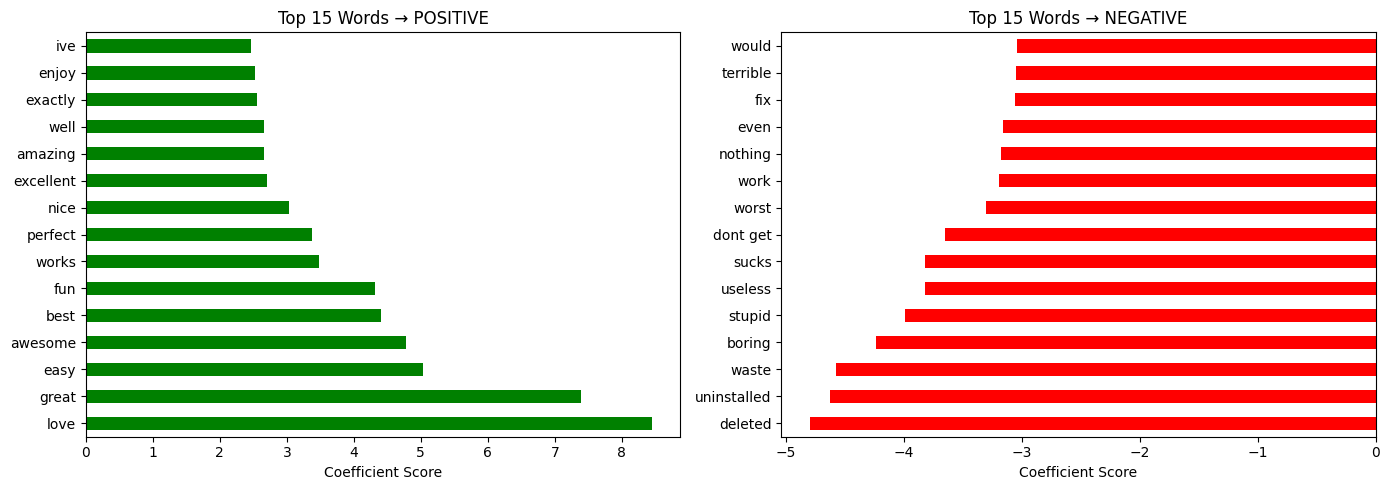

In [31]:
feature_names = tfidf.get_feature_names_out()
lg_coef       = lg_model.coef_[0]

top_positive = pd.Series(lg_coef, index=feature_names).nlargest(15)
top_negative = pd.Series(lg_coef, index=feature_names).nsmallest(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

top_positive.plot(kind='barh', ax=ax1, color='green')
ax1.set_title('Top 15 Words → POSITIVE')
ax1.set_xlabel('Coefficient Score')

top_negative.plot(kind='barh', ax=ax2, color='red')
ax2.set_title('Top 15 Words → NEGATIVE')
ax2.set_xlabel('Coefficient Score')

plt.tight_layout()
plt.show()

In [32]:
def predict_sentiment(review_text):
    cleaned    = clean_text(review_text)
    vectorized = tfidf.transform([cleaned])
    prediction = lg_model.predict(vectorized)[0]
    probability= lg_model.predict_proba(vectorized)[0]
    sentiment  = "✅ POSITIVE" if prediction == 1 else "❌ NEGATIVE"
    confidence = max(probability) * 100
    print(f"Review     : {review_text[:80]}")
    print(f"Prediction : {sentiment}")
    print(f"Confidence : {confidence:.1f}%")
    print()

predict_sentiment("This product is absolutely amazing! Best purchase ever!")
predict_sentiment("Terrible quality, broke after one day. Complete waste of money.")
predict_sentiment("Fast delivery, exactly as described. Very happy with it!")
predict_sentiment("Worst product I have ever bought. Total disappointment.")

Review     : This product is absolutely amazing! Best purchase ever!
Prediction : ✅ POSITIVE
Confidence : 93.6%

Review     : Terrible quality, broke after one day. Complete waste of money.
Prediction : ❌ NEGATIVE
Confidence : 85.3%

Review     : Fast delivery, exactly as described. Very happy with it!
Prediction : ✅ POSITIVE
Confidence : 96.8%

Review     : Worst product I have ever bought. Total disappointment.
Prediction : ❌ NEGATIVE
Confidence : 82.1%



In [33]:
print("=" * 50)
print("      PROJECT 4 — FINAL SUMMARY")
print("=" * 50)
print(f"Total reviews analyzed : {len(df):,}")
print(f"Positive reviews       : {(df['Score']==1).sum():,} ({df['Score'].mean()*100:.1f}%)")
print(f"Negative reviews       : {(df['Score']==0).sum():,}")
print(f"Vocabulary size        : {len(tfidf.vocabulary_):,} words")
print(f"Best model             : {best_name}")
print(f"Best accuracy          : {best_acc*100:.2f}%")
print("=" * 50)
print("\nKey Insights:")
print("• Positive reviews use: 'great', 'love', 'best', 'perfect', 'fun'")
print("• Negative reviews use: 'waste', 'terrible', 'broken', 'awful'")
print("• TF-IDF + Logistic Regression is a strong NLP baseline")

      PROJECT 4 — FINAL SUMMARY
Total reviews analyzed : 20,000
Positive reviews       : 15,233 (76.2%)
Negative reviews       : 4,767
Vocabulary size        : 5,000 words
Best model             : Logistic Regression
Best accuracy          : 89.42%

Key Insights:
• Positive reviews use: 'great', 'love', 'best', 'perfect', 'fun'
• Negative reviews use: 'waste', 'terrible', 'broken', 'awful'
• TF-IDF + Logistic Regression is a strong NLP baseline
